In [1]:
import numpy as np
import umap
import matplotlib.pyplot as plt
from sklearn.manifold import TSNE
from sklearn.decomposition import PCA
import pandas as pd

In [2]:
orig_img = np.load('../data/orig_img.npy')
latent_img = np.load('../data/latent_img.npy')
orig_txt = np.load('../data/orig_txt.npy')
latent_txt = np.load('../data/latent_txt.npy')

In [14]:
orig = orig_txt
latent = latent_txt

reducer = umap.UMAP(random_state=42)
reduced_embeddings_umap = reducer.fit_transform(np.vstack((orig, latent)))
tsne = TSNE(n_components=2, random_state=42)
reduced_embeddings_tsne = tsne.fit_transform(np.vstack((orig, latent)))
pca = PCA(n_components=2, random_state=42)
reduced_embeddings_pca = pca.fit_transform(np.vstack((orig, latent)))

/p/project1/hai_pathology/luknarova/venvs/luknarova2/lib/python3.11/site-packages/umap/umap_.py:1945: UserWarning: n_jobs value 1 overridden to 1 by setting random_state. Use no seed for parallelism.
  warn(f"n_jobs value {self.n_jobs} overridden to 1 by setting random_state. Use no seed for parallelism.")


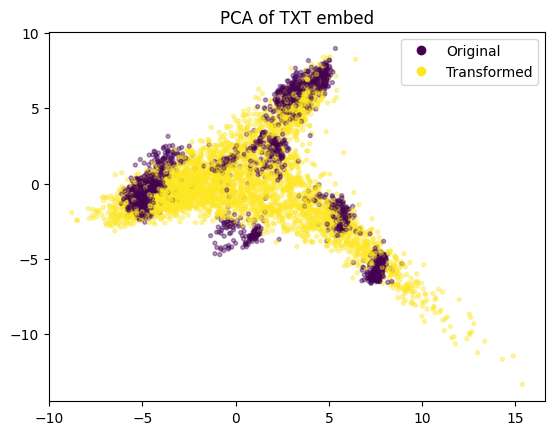

In [17]:
l = len(orig)
reduced = reduced_embeddings_pca
s = 8
alpha = 0.4
title = 'PCA of TXT embed'
X = reduced[:l, ]
Y = reduced[l:,]
data = np.concatenate([X,Y])
classes = np.concatenate([np.repeat('Original', X.shape[0]),
                          np.repeat('Transformed', Y.shape[0])])
plot_idx = np.random.permutation(data.shape[0])
colors,labels = pd.factorize(classes)
fig, ax = plt.subplots()
sc = ax.scatter(data[plot_idx, 0],
           data[plot_idx, 1],
           c=colors[plot_idx],
           alpha=alpha,
               s =s)

h = lambda c: plt.Line2D([],[],color=c, ls="",marker="o")
plt.legend(handles=[h(sc.cmap(sc.norm(i))) for i in range(len(labels))],
           labels=list(labels))
plt.title(title)

plt.savefig('../plots/PCA_emb_txt.png')

plt.show()